# **Milestone** | Exploratory Analysis of Olympic Athletes


<div style="text-align: center;">
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/5/5c/Olympic_rings_without_rims.svg/2560px-Olympic_rings_without_rims.svg.png" alt="The Olympic Rings" width="320"/>
</div>



# Introduction

In this Milestone, you will analyze a dataset containing information on Olympic medalists from 1896 to 2016. Your goal is to apply practical data analysis skills to explore trends, clean inconsistencies, and generate insights that will support data-driven journalism about the athletes, countries, and events that have shaped Olympic history.


### Dataset Description

You will use the `olympics.csv` dataset in the `datasets` folder to complete your analysis. Every row represents one athlete's participation in a specific Olympic event. The dataset contains the following columns:

* **ID**: A unique identifying number of each athlete
* **Name**: The name of each athlete
* **Sex**: M or F
* **Age**: The age of an athlete, in years
* **Height**: The height of an athlete, in centimeters
* **Weight**: The weight of an athlete, in kilograms
* **Team**: The name of the athlete’s team. Not always the name of a country.
* **NOC**: National Olympic Committee’s 3 letter code
* **Games**: Year and season
* **Season**: Summer or Winter
* **City**: Host city
* **Sport**: The  or category of olympic event/activity
* **Event**: specific event within a sport, e.g. Men’s 400 meters breaststroke.
* **Medal**: Gold, Silver, Bronze
* **Region**: Name of athlete’s country


To start, import the pandas library, load the data into a DataFrame and preview the first 5 rows.

In [1]:
# import the pandas library
import pandas as pd

# load the data into a dataframe
df = pd.read_csv("datasets/olympics.csv")

# preview the dataframe
df.head()


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region
0,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark
1,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze,Finland
2,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze,Finland
3,16,Juhamatti Tapio Aaltonen,M,28.0,184.0,85.0,Finland,FIN,2014 Winter,2014,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze,Finland
4,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze,Finland


## Task 1: Data Inspection
Start by inspecting the dataset to understand its structure and the types of questions you can ask. You'll familiarize yourself with the data columns and initial statistics.

In [2]:
# Inspect the numbers of rows and columns
df.shape


(39783, 16)

In [3]:
# Print out all the column names
df.columns


Index(['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games',
       'Year', 'Season', 'City', 'Sport', 'Event', 'Medal', 'region'],
      dtype='object')

In [4]:
# Inspect column data types, null values, and other info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39783 entries, 0 to 39782
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      39783 non-null  int64  
 1   Name    39783 non-null  object 
 2   Sex     39783 non-null  object 
 3   Age     39051 non-null  float64
 4   Height  31072 non-null  float64
 5   Weight  30456 non-null  float64
 6   Team    39783 non-null  object 
 7   NOC     39783 non-null  object 
 8   Games   39783 non-null  object 
 9   Year    39783 non-null  int64  
 10  Season  39783 non-null  object 
 11  City    39783 non-null  object 
 12  Sport   39783 non-null  object 
 13  Event   39783 non-null  object 
 14  Medal   39783 non-null  object 
 15  region  39774 non-null  object 
dtypes: float64(3), int64(2), object(11)
memory usage: 4.9+ MB


As you're reviewing the .info() output from the dataset, you should notice there are missing values some of the columns! Ask ChatGPT to recommend approaches for dealing with missing data in your analysis.

<div style="border: 3px solid #30EE99; background-color: #f0fff4; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
  <span style="font-size: 10pt;">
    <strong>Try This AI Prompt:</strong> I’m working with a dataset of Olympic medalists, and I’ve noticed some missing values in columns like Age, Height, Weight, and Region. I’m planning to ignore these missing values. Is this a reasonable approach for my analysis, or are there any important considerations I should be aware of before doing so?


  </span>
</div>

In [5]:
# Use unique() to examine the types of medals in the dataset.
df['Medal'].unique()


array(['Gold', 'Bronze', 'Silver'], dtype=object)

## Task 2: Data Cleaning
Now that we have a sense of the data, let's clean it to make sure it's ready for analysis.

<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Hint: </strong>When renaming/dropping columns, make sure to assign the result back to the dataframe to ensure that the new column names <em> replace </em> the old ones in your dataset.
</span>
</div>

In [6]:
# Rename 'NOC' column to 'CountryCode'
# Rename 'region' column to 'Country'
df = df.rename(columns={
    'NOC': 'CountryCode',
    'region': 'Country'
})


# preivew the dataframe again
df.head()


,ID,Name,Sex,Age,Height,Weight,Team,CountryCode,Games,Year,Season,City,Sport,Event,Medal,Country
0,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark
1,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze,Finland
2,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze,Finland
3,16,Juhamatti Tapio Aaltonen,M,28.0,184.0,85.0,Finland,FIN,2014 Winter,2014,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze,Finland
4,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze,Finland


In [7]:
# Remove the 'Team' column
df = df.drop(columns=['Team'])

# preivew the dataframe again
df.head()


,ID,Name,Sex,Age,Height,Weight,CountryCode,Games,Year,Season,City,Sport,Event,Medal,Country
0,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark
1,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,FIN,1920 Summer,1920,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze,Finland
2,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,FIN,1920 Summer,1920,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze,Finland
3,16,Juhamatti Tapio Aaltonen,M,28.0,184.0,85.0,FIN,2014 Winter,2014,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze,Finland
4,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze,Finland


## Task 3: Data Analysis

It's time to analyze the data to uncover factual information about athletes, medals, and events! You'll explore:
- Youngest and oldest medalists
- Medal count
- Number of unique events
- Average age of medalists
- Top 10 winningest countries by total medal count



**1.** What is the **youngest** age of an Olympic medalist?

In [8]:
# youngest age
df['Age'].min()


10.0

**2.** What is the **oldest** age of an Olympic medalist?

In [9]:
# oldest age
df['Age'].max()


73.0

**3.** Summarize the number of medals awarded by type. How many of each medal were awarded?

<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Hint: </strong>Think about which column contains the medal types, and how you could <em>count</em> the number of times each <em>value</em> appears.
</span>
</div>

In [10]:
# number of medals awarded by type
df['Medal'].value_counts()


Gold      13372
Bronze    13295
Silver    13116
Name: Medal, dtype: int64

**4.** How many (unique) events are there?

In [11]:
# Number of unique events
df['Event'].nunique()


756

**5.** How many (unique) sports are there?

In [12]:
# Number of unique sports
df['Sport'].nunique()


66

**6.** What is the average age of an Olympic medalist? Round the age to the nearest whole number.

In [13]:
# average age of an Olympic medalist?
round(df['Age'].mean())


26

**7A.** Among the 10 oldest medalists, what are the most common sports?


<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Hint: </strong>Start by sorting the data so the oldest athletes appear first. Then look only at a small slice of the data — you don’t need to analyze the full dataset to answer the question.
</span>
</div>

In [14]:
# most common sports among the 10 oldest medalists
oldest_medalists = df.sort_values(by='Age', ascending=False).head(10)
oldest_medalists[['Name', 'Age', 'Sport']]


,Name,Age,Sport
6072,John (Herbert Crawford-) Copley (Williamson-),73.0,Art Competitions
8279,Jozu Dupon,72.0,Art Competitions
33952,Oscar Gomer Swahn,72.0,Shooting
21901,Charles William Martin,71.0,Sailing
21902,Charles William Martin,71.0,Sailing
12614,Letitia Marion Hamilton,69.0,Art Competitions
34707,Oskar Thiede,69.0,Art Competitions
21198,Frederick William MacMonnies,68.0,Art Competitions
8340,Samuel Harding Duvall,68.0,Archery
25165,Louis Noverraz,66.0,Sailing


**7B.** To get a clearer view of the sports these athletes participated in, focus on the `Sport` column. After identifying the top 10 oldest athletes, count how many times each sport appears among them. This is a more precise way to identify the most common sports among oldest medalists!


In [15]:
# most common sports among the 10 oldest medalists with .value_counts
oldest_medalists['Sport'].value_counts()


Art Competitions    5
Sailing             3
Shooting            1
Archery             1
Name: Sport, dtype: int64

**8.** What are the 10 winningest countries in total medal count?

<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Hint: </strong>You'll need to count the number of times each country appears in the dataset but only display the top 10!
</span>
</div>

In [16]:
# What are the 10 winningest countries in total medal count?
df['Country'].value_counts().head(10)


USA          5637
Russia       3947
Germany      3756
UK           2068
France       1777
Italy        1637
Sweden       1536
Canada       1352
Australia    1349
Hungary      1135
Name: Country, dtype: int64

**9.** How many medals have been awarded in the sport of trampolining?

In [17]:
# Trampolining medals
df[df['Sport'] == 'Trampolining']['Medal'].count()


30

## Task 4: Find the Story
Now that you’ve explored the dataset and uncovered some key facts about athletes, events, and countries, it’s time to think like a data journalist.

Based on your findings:

- What trend, pattern, or outlier stood out to you?

- What topic would you pitch as the focus of a data-driven reporting article?

- Why do you think it’s interesting or important to explore further?

Write a short pitch (3–5 sentences) describing:

1. The angle you would pursue

2. What specific data points support it

3. What additional information you might want to gather

<div style="border: 3px solid #30EE99; background-color: #f0fff4; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
  <span style="font-size: 10pt;">
    <strong>Try This AI Prompt:</strong> I’ve explored a dataset about Olympic medalists and found [insert key findings]. I want to pitch a story based on these findings. Can you suggest a few ways to frame the story to make it interesting for a general audience?


  </span>
</div>


I would explore how age diversity shapes Olympic achievement showing that medalists have ranged from 10 to 73 years old. The data reveals that while the average medalist is 26, older athletes have succeeded in sports like sailing and art competitions, breaking expectations about athletic prime. To expand I’d gather personal accounts or historical records to understand how these older athletes maintained competitive performance across generations.



## LevelUp
Explore additional questions to dive deeper into the dataset and see how the insights you uncover might influence your pitch or reporting. These extra credit tasks offer a chance to refine your understanding and discover new angles for potential stories 😎



**1.** Use a combination of filters to find out how many gold medals were awarded to the United States?

In [18]:
# gold medals awarded to the United States
usa_gold = df[(df['Country'] == 'USA') & (df['Medal'] == 'Gold')]
len(usa_gold)


2638

**2.** List the Olympic Games in dataset, starting with the most recent

In [20]:
# Olympic Games in the dataset
df['Games'].unique()
sorted(df['Games'].unique(), reverse=True)


['2016 Summer',
 '2014 Winter',
 '2012 Summer',
 '2010 Winter',
 '2008 Summer',
 '2006 Winter',
 '2004 Summer',
 '2002 Winter',
 '2000 Summer',
 '1998 Winter',
 '1996 Summer',
 '1994 Winter',
 '1992 Winter',
 '1992 Summer',
 '1988 Winter',
 '1988 Summer',
 '1984 Winter',
 '1984 Summer',
 '1980 Winter',
 '1980 Summer',
 '1976 Winter',
 '1976 Summer',
 '1972 Winter',
 '1972 Summer',
 '1968 Winter',
 '1968 Summer',
 '1964 Winter',
 '1964 Summer',
 '1960 Winter',
 '1960 Summer',
 '1956 Winter',
 '1956 Summer',
 '1952 Winter',
 '1952 Summer',
 '1948 Winter',
 '1948 Summer',
 '1936 Winter',
 '1936 Summer',
 '1932 Winter',
 '1932 Summer',
 '1928 Winter',
 '1928 Summer',
 '1924 Winter',
 '1924 Summer',
 '1920 Summer',
 '1912 Summer',
 '1908 Summer',
 '1906 Summer',
 '1904 Summer',
 '1900 Summer',
 '1896 Summer']

**3.** What is the average medalist height in the most recent Winter Olympics. Format your answer into Feet' Inches''.

<div style="border: 3px solid #30EE99; background-color: #f0fff4; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
  <span style="font-size: 10pt;">
    <strong>Try This AI Prompt:</strong> "How can I convert 175 inches into feet and inches in Python? Can you show me the code for that?"
  </span>
</div>

In [21]:
# average medalist height in the most recent Winter Olympics
recent_winter = df[df['Season'] == 'Winter']
latest_year = recent_winter['Year'].max()
recent_winter = recent_winter[recent_winter['Year'] == latest_year]

avg_height_cm = recent_winter['Height'].mean()
avg_height_in = avg_height_cm / 2.54  # convert cm to inches
feet = int(avg_height_in // 12)
inches = int(avg_height_in % 12)

print(f"Average medalist height in the {latest_year} Winter Olympics: {feet}' {inches}''")



Average medalist height in the 2014 Winter Olympics: 5' 9''


**4.** What is the average medalist **weight** in the most recent Winter Olympics. Round the average weight to the nearest 2 decimals.

In [22]:
# Average medalist weight in the most recent Winter Olympics
round(recent_winter['Weight'].mean(), 2)


72.21

**5.** What is the average medalist **height** in the most recent Summer Olympics. Format your answer into Feet' Inches''.

In [23]:
# Average medalist height in the most recent Summer Olympics
recent_summer = df[df['Season'] == 'Summer']
latest_year_summer = recent_summer['Year'].max()
recent_summer = recent_summer[recent_summer['Year'] == latest_year_summer]

avg_height_cm_summer = recent_summer['Height'].mean()
avg_height_in_summer = avg_height_cm_summer / 2.54
feet_s = int(avg_height_in_summer // 12)
inches_s = int(avg_height_in_summer % 12)

print(f"Average medalist height in the {latest_year_summer} Summer Olympics: {feet_s}' {inches_s}''")



Average medalist height in the 2016 Summer Olympics: 5' 10''


**6.** What is the average medalist **weight** in the most recent Summer Olympics. Round the average weight to the nearest 2 decimals.

In [24]:
# Average medalist weight in the most recent Summer Olympics
round(recent_summer['Weight'].mean(), 2)


73.96

**7.** Import `plotly.express` and create a bar chart to visualize the top 10 countries with the most medals by using the data you assigned in Task 3.

<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Hint: </strong> You'll need to asssign top 10 winningest countries table from Task 3 to it's own variable!
</span>
</div>



In [25]:
# Import plotly express library
import plotly.express as px


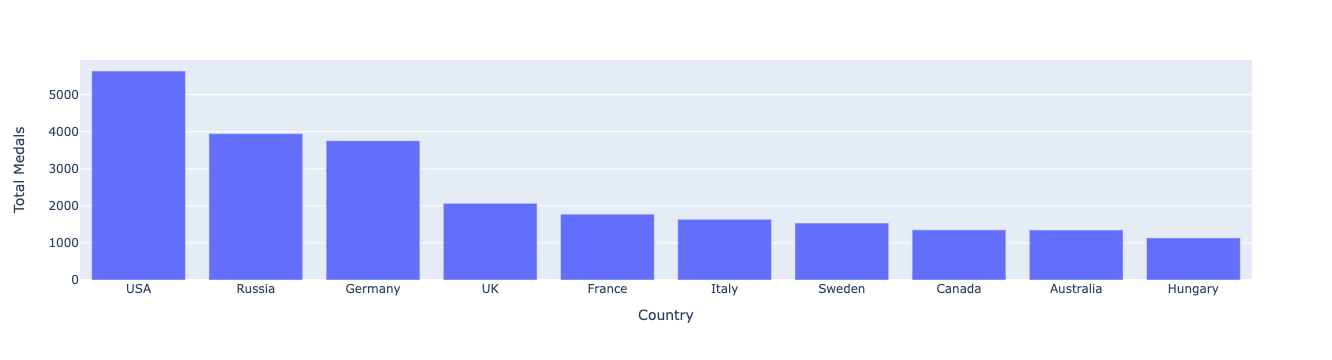

In [27]:
# Asssign top 10 winningest countries table to a variable
top10_countries = df['Country'].value_counts().head(10)


# Visualize the table as a bar chart
fig = px.bar(
    x=top10_countries.index,
    y=top10_countries.values,
    labels={'x': 'Country', 'y': 'Total Medals'},
)
fig.show()
